## Seaborn

Goal:
Create a Seaborn chart showing the **dynamic of commits per user in project1**.

Rules (from README):
- Analyze only users (exclude admins).
- Use only `checker` logs where `status = "ready"`.
- You can choose any palette.
- Line width = 3.
- Gray background.
- Figure height = 10, width = 1.5 × height.
- Title font size = 30.
- Axis labels font size = 15.

At the end:
Answer (based on the graph):
- Which user was the leader in the number of commits almost all of the time?
- Which user was the leader for only a short period of time?

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the SQLite database (we are inside src/ex08)
con = sqlite3.connect("../data/checking-logs.sqlite")

# Load only:
# - real users
# - project1
# - status = ready
q = """
SELECT uid, timestamp, numTrials
FROM checker
WHERE uid LIKE 'user_%'
  AND labname = 'project1'
  AND status = 'ready';
"""
df = pd.read_sql(q, con, parse_dates=["timestamp"])
con.close()

# Sort for cleaner lines
df = df.sort_values(["uid", "timestamp"])

df.head()

,uid,timestamp,numTrials
886,user_1,2020-05-14 20:56:08.898880,1
887,user_1,2020-05-14 20:58:02.313690,2
888,user_1,2020-05-14 20:58:46.322457,3
900,user_1,2020-05-14 21:08:15.434237,4
901,user_1,2020-05-14 21:10:14.867603,5


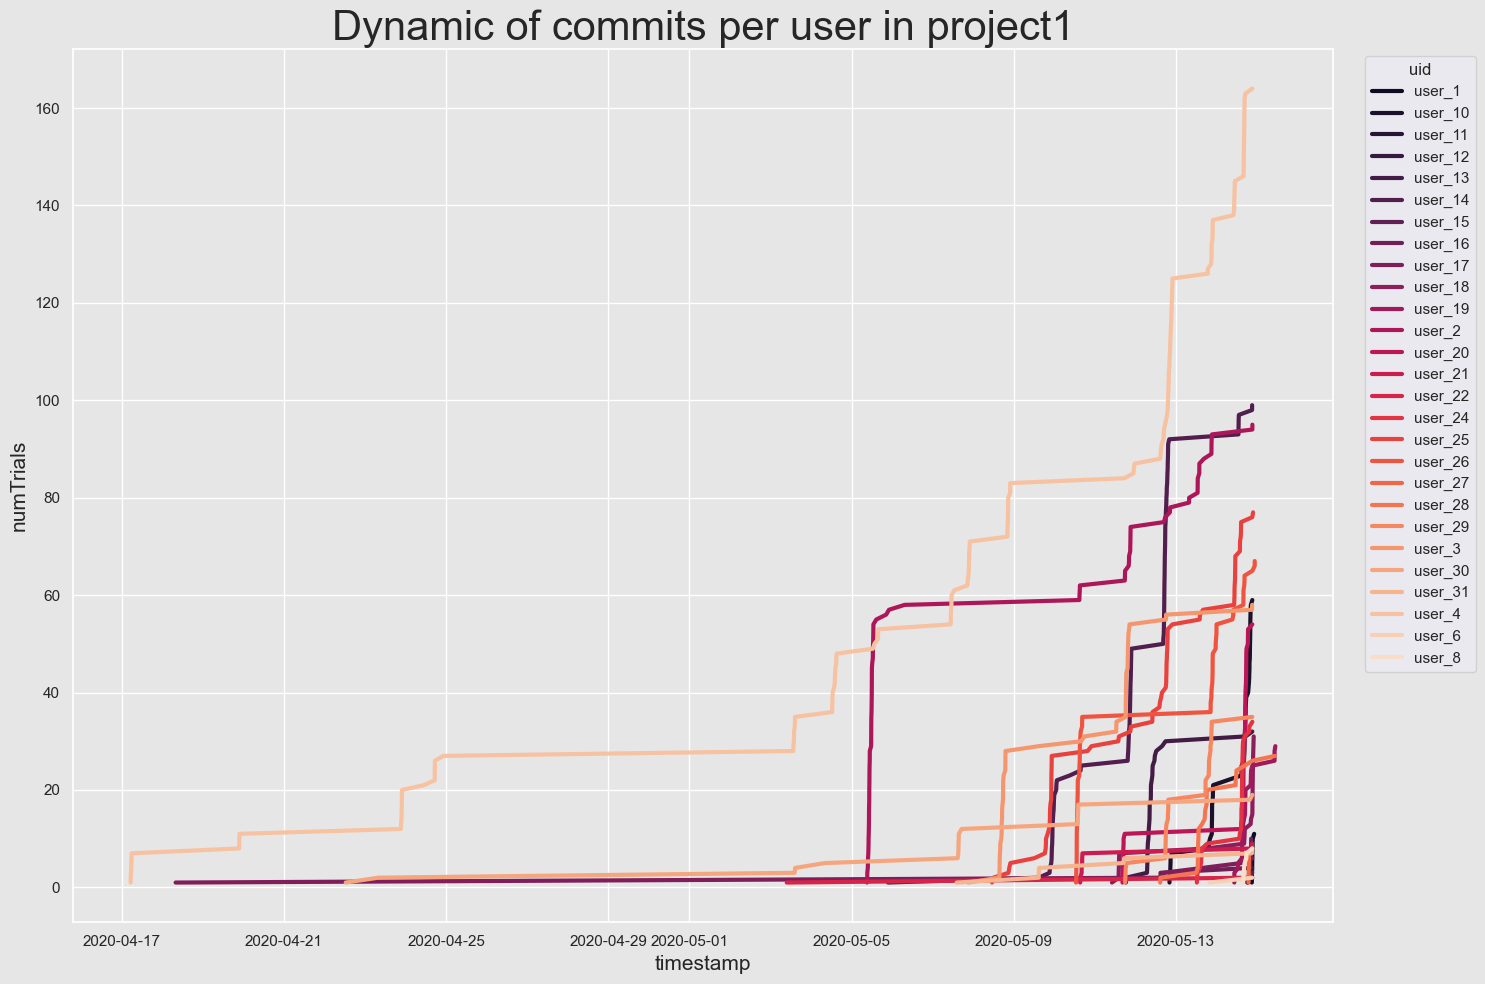

In [2]:
# Seaborn style (gray background feel)
sns.set_theme(style="darkgrid")

plt.figure(figsize=(15, 10))  # width = 1.5 * height, height=10
ax = sns.lineplot(
    data=df,
    x="timestamp",
    y="numTrials",
    hue="uid",
    linewidth=3,
    palette="rocket"  # choose any palette you like
)

# Background gray (explicit)
ax.set_facecolor("#E6E6E6")
ax.figure.set_facecolor("#E6E6E6")

ax.set_title("Dynamic of commits per user in project1", fontsize=30)
ax.set_xlabel("timestamp", fontsize=15)
ax.set_ylabel("numTrials", fontsize=15)

plt.legend(title="uid", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Answers

- Which user was the leader in the number of commits almost all of the time?  
  The answer is 

- Which user was the leader for only a short period of time?  
  The answer is 

In [4]:
# Build a daily leaderboard:
# 1) max numTrials per user per day
df["date"] = df["timestamp"].dt.date
daily_max = df.groupby(["date", "uid"])["numTrials"].max().unstack("uid")

# 2) forward-fill over days (so users keep their last known value)
daily_ffill = daily_max.ffill()

# 3) leader per day (uid with highest numTrials)
leader_per_day = daily_ffill.idxmax(axis=1)

# 4) count how many days each user leads
leader_counts = leader_per_day.value_counts()

leader_most = leader_counts.index[0]
leader_short = leader_counts.index[-1]  # smallest count among leaders

leader_most, leader_short, leader_counts.head()

('user_4',
 'user_2',
 user_4    17
 user_2     2
 Name: count, dtype: int64)